
=== Co-occurrence Matrix ===
       BRCA1  EGFR  MYC  PTEN  TP53
BRCA1      0     2    0     1     2
EGFR       2     0    1     2     3
MYC        0     1    0     1     2
PTEN       1     2    1     0     0
TP53       2     3    2     0     0


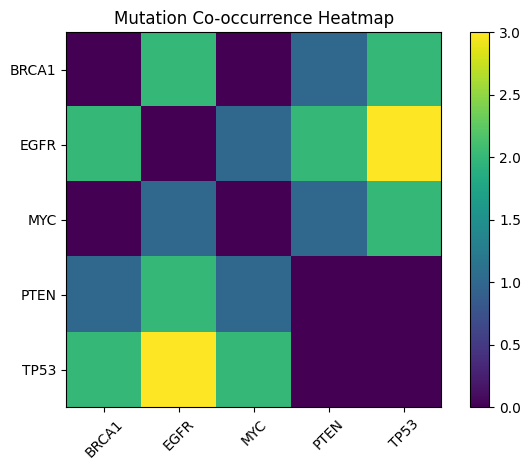

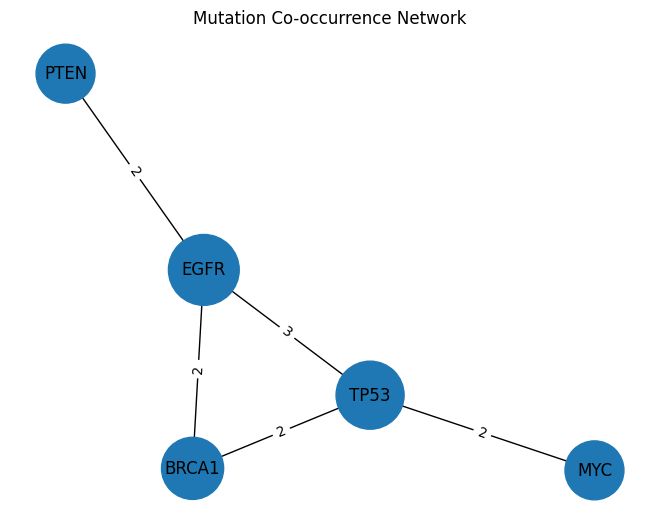

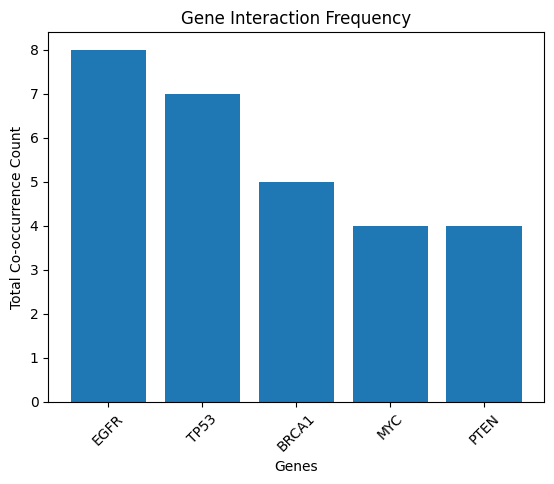


=== Strong Mutation Pairs ===
BRCA1 - EGFR: 2 times
BRCA1 - TP53: 2 times
EGFR - PTEN: 2 times
EGFR - TP53: 3 times
MYC - TP53: 2 times

=== Insights ===
Most frequent mutation pair: ('EGFR', 'TP53') occurring 3 times
Most connected gene: EGFR

Interpretation:
Highly co-occurring genes may indicate shared pathways or combined role in disease progression.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import networkx as nx

# -----------------------------
# STEP 1: SAMPLE DATA
# -----------------------------
patients = {
    "Patient_1": ["TP53","BRCA1","EGFR"],
    "Patient_2": ["TP53","MYC"],
    "Patient_3": ["BRCA1","EGFR","PTEN"],
    "Patient_4": ["TP53","EGFR"],
    "Patient_5": ["MYC","PTEN"],
    "Patient_6": ["TP53","BRCA1"],
    "Patient_7": ["EGFR","PTEN"],
    "Patient_8": ["TP53","MYC","EGFR"]
}

# -----------------------------
# STEP 2: CO-OCCURRENCE MATRIX
# -----------------------------
all_genes = sorted(list(set(itertools.chain(*patients.values()))))
matrix = pd.DataFrame(0, index=all_genes, columns=all_genes)

for genes in patients.values():
    for g1, g2 in itertools.combinations(genes, 2):
        matrix.loc[g1, g2] += 1
        matrix.loc[g2, g1] += 1

print("\n=== Co-occurrence Matrix ===")
print(matrix)

# -----------------------------
# STEP 3: HEATMAP (Improved)
# -----------------------------
plt.figure()
plt.imshow(matrix)
plt.colorbar()
plt.xticks(range(len(all_genes)), all_genes, rotation=45)
plt.yticks(range(len(all_genes)), all_genes)
plt.title("Mutation Co-occurrence Heatmap")
plt.tight_layout()
plt.show()

# -----------------------------
# STEP 4: NETWORK GRAPH (Improved)
# -----------------------------
G = nx.Graph()
threshold = 2

for i in matrix.index:
    for j in matrix.columns:
        if matrix.loc[i, j] >= threshold and i != j:
            G.add_edge(i, j, weight=matrix.loc[i, j])

plt.figure()
pos = nx.spring_layout(G)

node_sizes = [1000 + (matrix.loc[node].sum()*200) for node in G.nodes()]

nx.draw(G, pos, with_labels=True, node_size=node_sizes)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Mutation Co-occurrence Network")
plt.show()

# -----------------------------
# STEP 5: BAR CHART (NEW VISUAL)
# -----------------------------
gene_totals = matrix.sum(axis=1).sort_values(ascending=False)

plt.figure()
plt.bar(gene_totals.index, gene_totals.values)
plt.title("Gene Interaction Frequency")
plt.xlabel("Genes")
plt.ylabel("Total Co-occurrence Count")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# STEP 6: STRONG PAIRS
# -----------------------------
print("\n=== Strong Mutation Pairs ===")
for i in matrix.index:
    for j in matrix.columns:
        if matrix.loc[i, j] >= threshold and i < j:
            print(f"{i} - {j}: {matrix.loc[i, j]} times")

# -----------------------------
# STEP 7: INSIGHTS
# -----------------------------
print("\n=== Insights ===")

max_pair = None
max_value = 0

for i in matrix.index:
    for j in matrix.columns:
        if i < j and matrix.loc[i, j] > max_value:
            max_value = matrix.loc[i, j]
            max_pair = (i, j)

print(f"Most frequent mutation pair: {max_pair} occurring {max_value} times")

top_gene = gene_totals.idxmax()
print(f"Most connected gene: {top_gene}")

print("\nInterpretation:")
print("Highly co-occurring genes may indicate shared pathways or combined role in disease progression.")